Make the graph on the right! You need to implement an Automatic Higher or Lower
Game.

Set the bounds to between 1 to 20. The Graph has to keep guessing (max number of
guesses is 7) where if the guess is correct, then it stops, but if not we keep looping unt
we hit the max limit of 7.

Each time a number is guessed, the hint node should say higher or lower and the grapl
should account for this information and guess the next guess accordingly.

`Input: {"player_name": "Student", "guesses": [], "attempts": O, "lower_bound": 1,
"upper_bound": 20}`

Hint: It will need to adjust its bounds after every guess based on the hint provided by

In [1]:
from typing import TypedDict,List,Dict
from langgraph.graph import StateGraph , END
import random

In [2]:
class AgentState(TypedDict):
    name:str
    number:List[int]
    count:int

In [3]:
def greeting_node (state:AgentState)->AgentState:
    state['name'] = f"Hi there , {state['name']}"
    state['count'] = 0
    return state

def random_node(state:AgentState)->AgentState:
    
    state['number'].append(random.randint(0,10))
    state['count'] +=1
    return state

def should_continue(state:AgentState)->str:
    if state['count']<5 :
        print("Enter Looping",state['count'])
        return "Looping"
    else:
        return "Exit"

a= AgentState(name="ikrama",number=[],count=-1)
r=random_node(a)
r

{'name': 'ikrama', 'number': [2], 'count': 0}

In [4]:
graph = StateGraph(AgentState)
graph.add_node("greeting",greeting_node)
graph.add_node("random",random_node)
graph.add_edge("greeting","random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "Looping":"random",
        "Exit":END
    }
)
graph.set_entry_point("greeting")
app= graph.compile()

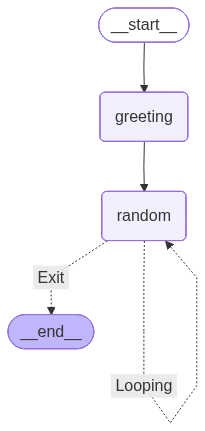

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
trail1 = AgentState(name="Ikrama",number=[],count=-2)
print(trail1)
app.invoke({'name':'Ikrama','number':[],'count':-1})

{'name': 'Ikrama', 'number': [], 'count': -2}
Enter Looping 1
Enter Looping 2
Enter Looping 3
Enter Looping 4


{'name': 'Hi there , Ikrama', 'number': [6, 5, 3, 2, 8], 'count': 5}

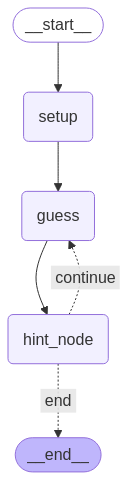